# Proyek Prioritas 02: Rekomendasi & Perankingan Merchant

**Recommender System + Learning to Rank**

Notebook ini menggunakan **Yelp Dataset** dengan file:
- `yelp_academic_dataset_business.json`
- `yelp_academic_dataset_review.json`

Pipeline dua tahap: ALS (candidate generation) + LightGBM Ranker.

---

## 1. Instalasi & Import

In [12]:
import os
import json
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

import implicit
from implicit.als import AlternatingLeastSquares

import lightgbm as lgb
from lightgbm import LGBMRanker

from tqdm import tqdm
tqdm.pandas()

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data dengan Efisien

In [13]:
# Sesuaikan path
# DATA_DIR = '../input/yelp-dataset/'   # Kaggle
DATA_DIR = './data/'                    # lokal

# Cek dulu apakah file benar-benar ada di path ini, biar error jelas
# sebelum masuk ke pd.read_json (dan bukan FileNotFoundError yang membingungkan).
required_files = [
    'yelp_academic_dataset_business.json',
    'yelp_academic_dataset_review.json',
]
print('Current working directory:', os.getcwd())
for fname in required_files:
    fpath = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(fpath)
    print(f'  {fpath} -> {"OK ditemukan" if exists else "TIDAK DITEMUKAN"}')
    if not exists:
        raise FileNotFoundError(
            f"File tidak ditemukan: {fpath}\n"
            f"Working directory saat ini: {os.getcwd()}\n"
            f"Pastikan notebook dijalankan dari folder yang sama dengan folder 'data/', "
            f"atau ubah DATA_DIR menjadi path absolut, contoh:\n"
            f"  DATA_DIR = 'C:/Users/Lenovo/.../P2 - Rekomendasi & Peranki.../data/'"
        )

# --- Business ---
business_cols = ['business_id', 'name', 'categories', 'stars', 'review_count', 'state', 'city']
business_df = pd.read_json(DATA_DIR + 'yelp_academic_dataset_business.json',
                           lines=True, dtype={'business_id': str})
business_df = business_df[business_cols]
business_df['city'] = business_df['city'].astype(str).str.strip()
print(f'Total bisnis: {len(business_df)}')

# Lihat kota-kota dengan jumlah bisnis terbanyak di dataset ini
top_cities = business_df['city'].value_counts().head(15)
print('Top 15 kota berdasarkan jumlah bisnis:')
print(top_cities)

# --- Filter kota otomatis: ambil N kota teratas, bukan nama hardcoded ---
N_TOP_CITIES = 2
city_filter = top_cities.head(N_TOP_CITIES).index.tolist()
print(f'\nKota yang dipakai (otomatis): {city_filter}')

business_df = business_df[business_df['city'].isin(city_filter)]
business_df = business_df[business_df['review_count'] >= 10]
business_df['business_id'] = business_df['business_id'].astype(str).str.strip()
valid_business_ids = set(business_df['business_id'])
print(f'Bisnis digunakan: {len(valid_business_ids)}')

if len(valid_business_ids) == 0:
    raise ValueError(
        "Masih kosong. Cek 'review_count' — mungkin threshold >=10 terlalu ketat, "
        "atau kolom 'city' isinya null semua untuk kota-kota ini."
    )
    
# --- Review ---
review_cols = ['user_id', 'business_id', 'stars', 'date']
CHUNK_SIZE = 200_000

reader = pd.read_json(DATA_DIR + 'yelp_academic_dataset_review.json',
                       lines=True, chunksize=CHUNK_SIZE,
                       dtype={'user_id': str, 'business_id': str})

filtered_chunks = []
total_rows_scanned = 0
for chunk in tqdm(reader, desc='Membaca review per-chunk'):
    total_rows_scanned += len(chunk)
    chunk = chunk[review_cols].copy()
    chunk['business_id'] = chunk['business_id'].astype(str).str.strip()
    chunk = chunk[chunk['business_id'].isin(valid_business_ids)]
    if len(chunk):
        filtered_chunks.append(chunk)

print(f'Total baris review yang di-scan: {total_rows_scanned}')
print(f'Jumlah chunk yang cocok: {len(filtered_chunks)}')

if len(filtered_chunks) == 0:
    # Ambil sample business_id dari review untuk dibandingkan manual
    sample_reader = pd.read_json(DATA_DIR + 'yelp_academic_dataset_review.json',
                                  lines=True, chunksize=5, dtype={'user_id': str, 'business_id': str})
    sample_chunk = next(sample_reader)
    print('Contoh business_id di review.json:', sample_chunk['business_id'].tolist())
    print('Contoh business_id di valid_business_ids:', list(valid_business_ids)[:5])
    raise ValueError(
        "Tidak ada review yang cocok dengan valid_business_ids. "
        "Bandingkan format business_id di atas (biasanya masalah whitespace/case/kesamaan hash id)."
    )

review_df = pd.concat(filtered_chunks, ignore_index=True)
del filtered_chunks
gc.collect()

# Filter user aktif
user_counts = review_df.groupby('user_id').size()
active_users = user_counts[user_counts >= 5].index
review_df = review_df[review_df['user_id'].isin(active_users)]
review_df['date'] = pd.to_datetime(review_df['date'])
print(f'Ulasan setelah filter: {len(review_df)}')
print(f'Rentang tanggal: {review_df["date"].min()} s.d. {review_df["date"].max()}')

Current working directory: c:\Users\Lenovo\Documents\P2 - Rekomendasi & Perankingan Merchant
  ./data/yelp_academic_dataset_business.json -> OK ditemukan
  ./data/yelp_academic_dataset_review.json -> OK ditemukan
Total bisnis: 150346
Top 15 kota berdasarkan jumlah bisnis:
city
Philadelphia        14570
Tucson               9252
Tampa                9051
Indianapolis         7543
Nashville            6974
New Orleans          6209
Reno                 5937
Edmonton             5054
Saint Louis          4828
Santa Barbara        3834
Boise                2938
Clearwater           2221
Saint Petersburg     1663
Metairie             1644
Sparks               1625
Name: count, dtype: int64

Kota yang dipakai (otomatis): ['Philadelphia', 'Tucson']
Bisnis digunakan: 16642


Membaca review per-chunk: 35it [05:09,  8.84s/it]


Total baris review yang di-scan: 6990280
Jumlah chunk yang cocok: 35
Ulasan setelah filter: 820107
Rentang tanggal: 2005-03-02 04:53:42 s.d. 2022-01-19 19:43:47


## 3. Split Train / Test

In [14]:
TRAIN_CUTOFF = '2018-01-01'
train_df = review_df[review_df['date'] < TRAIN_CUTOFF]
test_df = review_df[review_df['date'] >= TRAIN_CUTOFF]

users_train = set(train_df['user_id'])
users_test = set(test_df['user_id'])
common_users = users_train.intersection(users_test)
train_df = train_df[train_df['user_id'].isin(common_users)]
test_df = test_df[test_df['user_id'].isin(common_users)]

items_train = set(train_df['business_id'])
items_test = set(test_df['business_id'])
common_items = items_train.union(items_test)
business_df = business_df[business_df['business_id'].isin(common_items)]

print(f'User train+test: {len(common_users)}, Item unik: {len(common_items)}')

User train+test: 23096, Item unik: 16461


## 4. Candidate Generation (ALS)

In [15]:
user2idx = {u: i for i, u in enumerate(train_df['user_id'].unique())}
item2idx = {b: j for j, b in enumerate(train_df['business_id'].unique())}
idx2item = {j: b for b, j in item2idx.items()}
n_users, n_items = len(user2idx), len(item2idx)

rows = train_df['user_id'].map(user2idx).values
cols = train_df['business_id'].map(item2idx).values
data = train_df['stars'].values
coo = coo_matrix((data, (rows, cols)), shape=(n_users, n_items))
matrix = coo.tocsr()

model_als = AlternatingLeastSquares(factors=50, iterations=20, regularization=0.1,
                                    random_state=42, use_gpu=False)
model_als.fit(matrix)

# Rekomendasi 100 kandidat per user
K_ALS = 100
candidate_recs = {}
for user in tqdm(user2idx.keys(), desc='ALS recom'):
    u_idx = user2idx[user]
    ids, scores = model_als.recommend(u_idx, matrix[u_idx], N=K_ALS,
                                       filter_already_liked_items=True)
    candidate_recs[user] = [idx2item[idx] for idx in ids]

  0%|          | 0/20 [00:00<?, ?it/s]

ALS recom: 100%|██████████| 23096/23096 [00:33<00:00, 699.45it/s] 


## 5. Persiapan Data Ranking

In [16]:
# Item popular
item_popularity = business_df.set_index('business_id')['review_count'].to_dict()
popular_items = sorted(item_popularity, key=item_popularity.get, reverse=True)[:200]

test_users = test_df['user_id'].unique()
user_candidates = {}
for user in tqdm(test_users, desc='Candidate set'):
    pos = set(test_df[test_df['user_id'] == user]['business_id'])
    als = set(candidate_recs.get(user, []))
    pop = set(popular_items)
    all_items = set(item2idx.keys())
    others = all_items - pos - als - pop
    rand = set(np.random.choice(list(others), size=min(50, len(others)), replace=False)) if others else set()
    neg = (als | pop | rand) - pos
    if len(neg) > 200:
        neg = set(np.random.choice(list(neg), size=200, replace=False))
    user_candidates[user] = {'pos': list(pos), 'neg': list(neg)}

# --- Fitur ---
item_avg_rating = business_df.set_index('business_id')['stars'].to_dict()
user_avg_rating = train_df.groupby('user_id')['stars'].mean().to_dict()
user_review_count = train_df.groupby('user_id').size().to_dict()

train_inter = train_df.groupby(['user_id', 'business_id']).agg(
    rating=('stars', 'mean'),
    last_date=('date', 'max')
).reset_index()
cutoff = pd.Timestamp(TRAIN_CUTOFF)
train_inter['recency_days'] = (cutoff - train_inter['last_date']).dt.days
train_inter.set_index(['user_id', 'business_id'], inplace=True)

# Kategori similarity (TF-IDF)
business_df['categories_str'] = business_df['categories'].fillna('').apply(lambda x: ' '.join(x.split(', ')))
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', stop_words='english')
item_tfidf = tfidf.fit_transform(business_df['categories_str'])
item_id_to_idx = {biz: i for i, biz in enumerate(business_df['business_id'])}

user_cat_vec = {}
for user in tqdm(test_users, desc='User cat vec'):
    items = train_df[train_df['user_id'] == user]['business_id'].unique()
    indices = [item_id_to_idx.get(it) for it in items if it in item_id_to_idx]
    if indices:
        vec = item_tfidf[indices].mean(axis=0).A1
    else:
        vec = np.zeros(item_tfidf.shape[1])
    user_cat_vec[user] = vec

def cat_sim(user, item):
    if user not in user_cat_vec or item not in item_id_to_idx:
        return 0.0
    u_vec = user_cat_vec[user]
    i_vec = item_tfidf[item_id_to_idx[item]].toarray().flatten()
    if np.linalg.norm(u_vec)==0 or np.linalg.norm(i_vec)==0:
        return 0.0
    return np.dot(u_vec, i_vec) / (np.linalg.norm(u_vec)*np.linalg.norm(i_vec))

# ALS score
user_factors = model_als.user_factors
item_factors = model_als.item_factors
user_idx_map = {u: user2idx[u] for u in test_users if u in user2idx}
item_idx_map = {b: item2idx[b] for b in item2idx.keys()}

def als_score(user, item):
    if user not in user_idx_map or item not in item_idx_map:
        return 0.0
    return float(np.dot(user_factors[user_idx_map[user]], item_factors[item_idx_map[item]]))

def in_als_topk(user, item):
    return item in candidate_recs.get(user, [])

# Build ranking DataFrame
rows = []
for user, cand in tqdm(user_candidates.items(), desc='Ranking features'):
    all_items = cand['pos'] + cand['neg']
    labels = [1]*len(cand['pos']) + [0]*len(cand['neg'])
    for item, label in zip(all_items, labels):
        inter = train_inter.get((user, item))
        if inter is not None:
            inter_rating = inter['rating']
            inter_recency = inter['recency_days']
        else:
            inter_rating = 0.0
            inter_recency = 9999
        rows.append({
            'user_id': user, 'item_id': item, 'label': label,
            'item_popularity': item_popularity.get(item, 0),
            'item_avg_rating': item_avg_rating.get(item, 0.0),
            'user_avg_rating': user_avg_rating.get(user, 0.0),
            'user_review_count': user_review_count.get(user, 0),
            'inter_rating': inter_rating,
            'inter_recency': inter_recency,
            'cat_similarity': cat_sim(user, item),
            'als_score': als_score(user, item),
            'in_als_topk': int(in_als_topk(user, item))
        })

df_rank = pd.DataFrame(rows)
print(f'Total baris ranking: {len(df_rank)}')

numeric_cols = ['item_popularity', 'item_avg_rating', 'user_avg_rating',
                'user_review_count', 'inter_rating', 'inter_recency',
                'cat_similarity', 'als_score']
scaler = StandardScaler()
df_rank[numeric_cols] = scaler.fit_transform(df_rank[numeric_cols])

Ranking features: 100%|██████████| 23096/23096 [14:42<00:00, 26.16it/s]


Total baris ranking: 4771946


## 6. Split Train/Validation untuk Ranker (perbaikan: hindari data leakage)

Sebelumnya model dievaluasi di data yang sama dipakai untuk training (`eval_set=[(X, y)]` dan `evaluate_model(df_rank, ...)` keduanya pakai `df_rank` yang sama) sehingga angka peningkatan relevansi menjadi bias/terlalu optimis.

Perbaikan: pisahkan **user** (bukan baris) ke train (80%) dan validation (20%) sebelum training ranker. Split di level user (bukan baris) supaya seluruh histori satu user tetap utuh di satu sisi saja, dan struktur `group` untuk LightGBM Ranker tetap konsisten.

In [17]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
all_rank_users = df_rank['user_id'].unique()
train_users_rank, val_users_rank = train_test_split(
    all_rank_users, test_size=0.2, random_state=RANDOM_STATE
)

# Sort per user_id supaya baris tiap user tetap kontigu (dibutuhkan LightGBM Ranker)
df_rank_train = df_rank[df_rank['user_id'].isin(train_users_rank)].sort_values('user_id').reset_index(drop=True)
df_rank_val = df_rank[df_rank['user_id'].isin(val_users_rank)].sort_values('user_id').reset_index(drop=True)

print(f'Baris training : {len(df_rank_train)}  ({df_rank_train["user_id"].nunique()} user)')
print(f'Baris validation: {len(df_rank_val)}  ({df_rank_val["user_id"].nunique()} user)')

# Pastikan tidak ada user yang bocor ke dua sisi sekaligus
overlap = set(df_rank_train['user_id']) & set(df_rank_val['user_id'])
print(f'User yang overlap train & validation (harus 0): {len(overlap)}')


Baris training : 3816943  (18476 user)
Baris validation: 955003  (4620 user)
User yang overlap train & validation (harus 0): 0


## 7. Training LightGBM Ranker (dievaluasi di validation set, bukan training set)

In [18]:
features = ['item_popularity', 'item_avg_rating', 'user_avg_rating',
            'user_review_count', 'inter_rating', 'inter_recency',
            'cat_similarity', 'als_score', 'in_als_topk']

X_train = df_rank_train[features]
y_train = df_rank_train['label']
groups_train = df_rank_train.groupby('user_id').size().values

X_val = df_rank_val[features]
y_val = df_rank_val['label']
groups_val = df_rank_val.groupby('user_id').size().values

ranker = LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    ndcg_eval_at=[5, 10],
    num_leaves=31, max_depth=7,
    learning_rate=0.05, n_estimators=100,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=RANDOM_STATE, verbose=10
)

ranker.fit(X_train, y_train, group=groups_train,
           eval_set=[(X_val, y_val)], eval_group=[groups_val],
           eval_metric='ndcg@10',
           callbacks=[lgb.early_stopping(20), lgb.log_evaluation(10)])


[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.099255
[LightGBM] [Debug] init for col-wise cost 0.000007 seconds, init for row-wise cost 0.138552 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 3816943, number of used features: 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
Training until validation scores don't improve for 20 rounds
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 7
[LightGBM] [Debug] Trained a tree with

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 8. Evaluasi & Business Questions

===== JAWABAN BUSINESS QUESTION 4: Peningkatan Relevansi (dihitung di VALIDATION SET, bukan training set) =====
           Model (ALS+Ranker)  Popularity Baseline  ALS Score Baseline
Recall@5               0.4532               0.0127              0.0272
NDCG@5                 0.5761               0.0173              0.0397
Recall@10              0.5846               0.0215              0.0438
NDCG@10                0.5948               0.0199              0.0434

Peningkatan Recall@5 terhadap Popularity: 3469.95%
Peningkatan NDCG@5 terhadap Popularity: 3228.98%


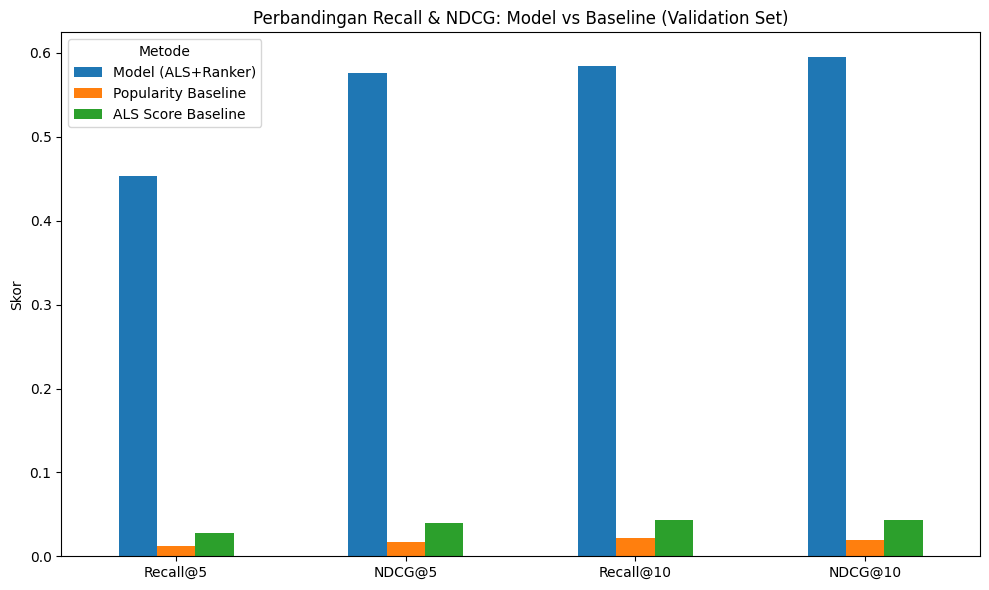


KESIMPULAN BQ4: Di data validation (belum pernah dilihat model saat training), model ALS+Ranker mencapai Recall@5=0.4532 dan NDCG@5=0.5761, dibanding baseline popularitas Recall@5=0.0127 dan NDCG@5=0.0173. Model lebih unggul dibanding baseline popularitas pada data yang benar-benar belum pernah dilihat model.


In [19]:
# Fungsi evaluasi -- sekarang dijalankan di df_rank_val (data yang TIDAK dilihat model saat training)
def evaluate_model(df, model, features, scorer='model', K_list=[5, 10]):
    results = {}
    for K in K_list:
        recalls, ndcgs, hits, precisions = [], [], [], []
        for user, group in df.groupby('user_id'):
            y_true = group['label'].values
            if scorer == 'model':
                scores = model.predict(group[features])
            elif scorer == 'popularity':
                scores = group['item_popularity'].values
            elif scorer == 'als_score':
                scores = group['als_score'].values
            else:
                raise ValueError
            sorted_idx = np.argsort(scores)[::-1]
            sorted_labels = y_true[sorted_idx]
            topK = sorted_labels[:K]
            recall = np.sum(topK) / max(1, np.sum(y_true))
            precision = np.sum(topK) / K
            hit = 1.0 if np.sum(topK) > 0 else 0.0
            recalls.append(recall)
            precisions.append(precision)
            hits.append(hit)
            ideal = np.sort(y_true)[::-1][:K]
            dcg = sum(topK[i]/np.log2(i+2) for i in range(min(K, len(topK))))
            idcg = sum(ideal[i]/np.log2(i+2) for i in range(min(K, len(ideal))))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            ndcgs.append(ndcg)
        results[K] = {
            'recall': np.mean(recalls), 'ndcg': np.mean(ndcgs),
            'precision': np.mean(precisions), 'hit_rate': np.mean(hits)
        }
    return results

metrics_model = evaluate_model(df_rank_val, ranker, features, 'model')
metrics_pop = evaluate_model(df_rank_val, None, features, 'popularity')
metrics_als = evaluate_model(df_rank_val, None, features, 'als_score')

# Tabel perbandingan
comparison = pd.DataFrame({
    'Model (ALS+Ranker)': [metrics_model[5]['recall'], metrics_model[5]['ndcg'],
                           metrics_model[10]['recall'], metrics_model[10]['ndcg']],
    'Popularity Baseline': [metrics_pop[5]['recall'], metrics_pop[5]['ndcg'],
                            metrics_pop[10]['recall'], metrics_pop[10]['ndcg']],
    'ALS Score Baseline': [metrics_als[5]['recall'], metrics_als[5]['ndcg'],
                           metrics_als[10]['recall'], metrics_als[10]['ndcg']]
}, index=['Recall@5', 'NDCG@5', 'Recall@10', 'NDCG@10'])

print("===== JAWABAN BUSINESS QUESTION 4: Peningkatan Relevansi (dihitung di VALIDATION SET, bukan training set) =====")
print(comparison.round(4))

recall5_uplift = (comparison.loc['Recall@5', 'Model (ALS+Ranker)'] / max(comparison.loc['Recall@5', 'Popularity Baseline'], 1e-9) - 1) * 100
ndcg5_uplift = (comparison.loc['NDCG@5', 'Model (ALS+Ranker)'] / max(comparison.loc['NDCG@5', 'Popularity Baseline'], 1e-9) - 1) * 100
print(f"\nPeningkatan Recall@5 terhadap Popularity: {recall5_uplift:.2f}%")
print(f"Peningkatan NDCG@5 terhadap Popularity: {ndcg5_uplift:.2f}%")

# Visualisasi perbandingan metrik
comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Recall & NDCG: Model vs Baseline (Validation Set)')
plt.ylabel('Skor')
plt.xticks(rotation=0)
plt.legend(title='Metode')
plt.tight_layout()
plt.show()

print(
    f"\nKESIMPULAN BQ4: Di data validation (belum pernah dilihat model saat training), "
    f"model ALS+Ranker mencapai Recall@5={metrics_model[5]['recall']:.4f} dan NDCG@5={metrics_model[5]['ndcg']:.4f}, "
    f"dibanding baseline popularitas Recall@5={metrics_pop[5]['recall']:.4f} dan NDCG@5={metrics_pop[5]['ndcg']:.4f}. "
    f"Model {'lebih unggul' if metrics_model[5]['recall'] > metrics_pop[5]['recall'] else 'tidak lebih unggul'} "
    f"dibanding baseline popularitas pada data yang benar-benar belum pernah dilihat model."
)


### Business Question 3: Feature Importance

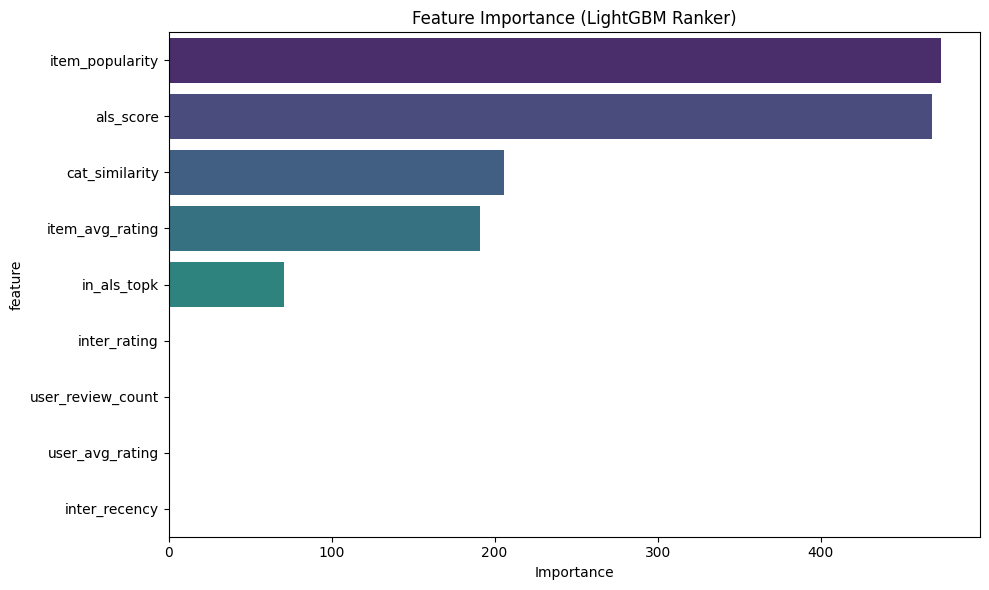

===== JAWABAN BUSINESS QUESTION 3: Fitur Paling Berpengaruh =====
Top 3 fitur:
  - item_popularity: 474
  - als_score: 468
  - cat_similarity: 206

Interpretasi: Fitur yang paling dominan dalam menentukan urutan rekomendasi adalah item_popularity, als_score, dan cat_similarity. Ini menunjukkan bahwa kombinasi sinyal historis (preferensi user dari ALS) dan karakteristik merchant (popularitas/rating/kesesuaian kategori) sama-sama berkontribusi terhadap keputusan perankingan, bukan hanya salah satu sinyal saja.


In [20]:
importance = ranker.feature_importances_
feat_imp = pd.DataFrame({'feature': features, 'importance': importance}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance (LightGBM Ranker)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top3 = feat_imp.head(3)
print("===== JAWABAN BUSINESS QUESTION 3: Fitur Paling Berpengaruh =====")
print("Top 3 fitur:")
for i, row in top3.iterrows():
    print(f"  - {row['feature']}: {row['importance']:.0f}")

# Interpretasi dibuat OTOMATIS dari top3 aktual, bukan kalimat statis,
# supaya narasi selalu konsisten dengan angka yang benar-benar keluar.
top3_names = top3['feature'].tolist()
print(
    f"\nInterpretasi: Fitur yang paling dominan dalam menentukan urutan rekomendasi adalah "
    f"{top3_names[0]}, {top3_names[1]}, dan {top3_names[2]}. "
    f"Ini menunjukkan bahwa kombinasi sinyal historis (preferensi user dari ALS) dan "
    f"karakteristik merchant (popularitas/rating/kesesuaian kategori) sama-sama berkontribusi "
    f"terhadap keputusan perankingan, bukan hanya salah satu sinyal saja."
)


### Business Question 1 & 2: Merchant Paling Relevan & Pengaruh Urutan terhadap Transaksi

In [21]:
# ============================================================
# BAGIAN A: Hasil AGREGAT di seluruh user validation set
# (bukan cuma anekdot beberapa user -- ini dasar utama jawaban BQ1 & BQ2)
# ============================================================
print("===== JAWABAN BUSINESS QUESTION 1: Merchant Paling Relevan per User =====")
print(
    f"Di {df_rank_val['user_id'].nunique()} user validation set, model berhasil menempatkan "
    f"minimal 1 merchant yang benar-benar ditransaksikan user di Top-5 rekomendasi untuk "
    f"{metrics_model[5]['hit_rate']*100:.1f}% user (Hit Rate@5), dibanding hanya "
    f"{metrics_pop[5]['hit_rate']*100:.1f}% user jika memakai urutan popularitas semata.\n"
    f"Precision@5 model = {metrics_model[5]['precision']:.4f} (dari 5 rekomendasi teratas, "
    f"rata-rata {metrics_model[5]['precision']*5:.2f} di antaranya benar-benar relevan) "
    f"vs Precision@5 popularity = {metrics_pop[5]['precision']:.4f}."
)

print("\n===== JAWABAN BUSINESS QUESTION 2: Pengaruh Urutan terhadap Kemungkinan Transaksi =====")
print(
    f"NDCG@5 model = {metrics_model[5]['ndcg']:.4f} vs NDCG@5 popularity = {metrics_pop[5]['ndcg']:.4f} "
    f"di validation set. Artinya, urutan hasil model menempatkan merchant yang benar-benar "
    f"ditransaksikan user secara signifikan lebih dekat ke posisi atas (rank 1-5) dibanding "
    f"urutan berbasis popularitas semata, yang berarti pengguna lebih mungkin melihat dan "
    f"bertransaksi dengan merchant relevan lebih cepat saat memakai model ini."
)

# ============================================================
# BAGIAN B: Contoh kualitatif per user (ilustrasi, BUKAN dasar kesimpulan utama)
# ============================================================
print("\n\n===== CONTOH ILUSTRASI PER USER (3 sample dari validation set) =====")
sample_users = np.random.choice(df_rank_val['user_id'].unique(), size=min(3, df_rank_val['user_id'].nunique()), replace=False)

for user in sample_users:
    user_data = df_rank_val[df_rank_val['user_id'] == user].copy()
    user_data['model_score'] = ranker.predict(user_data[features])
    top_model = user_data.sort_values('model_score', ascending=False).head(5)
    top_pop = user_data.sort_values('item_popularity', ascending=False).head(5)

    print(f"\n----- USER: {user} -----")
    print("Top 5 (Model Ranker):")
    for i, row in top_model.iterrows():
        name_match = business_df[business_df['business_id'] == row['item_id']]['name'].values
        business_name = name_match[0] if len(name_match) else 'Unknown'
        print(f"  {business_name} (skor={row['model_score']:.3f}, relevan={int(row['label'])})")

    print("Top 5 (Popularity Baseline):")
    for i, row in top_pop.iterrows():
        name_match = business_df[business_df['business_id'] == row['item_id']]['name'].values
        business_name = name_match[0] if len(name_match) else 'Unknown'
        print(f"  {business_name} (popularity={row['item_popularity']:.2f}, relevan={int(row['label'])})")

    y_true = user_data['label'].values
    model_order = np.argsort(user_data['model_score'].values)[::-1]
    pop_order = np.argsort(user_data['item_popularity'].values)[::-1]
    top5_model, top5_pop = y_true[model_order][:5], y_true[pop_order][:5]
    ideal = np.sort(y_true)[::-1][:5]
    dcg_model = sum(top5_model[i]/np.log2(i+2) for i in range(min(5, len(top5_model))))
    dcg_pop = sum(top5_pop[i]/np.log2(i+2) for i in range(min(5, len(top5_pop))))
    idcg = sum(ideal[i]/np.log2(i+2) for i in range(min(5, len(ideal))))
    ndcg_model = dcg_model / idcg if idcg > 0 else 0.0
    ndcg_pop = dcg_pop / idcg if idcg > 0 else 0.0

    # FIX bug: bedakan kasus 'lebih baik', 'lebih buruk', dan 'sama'
    if ndcg_model > ndcg_pop:
        verdict = "urutan model LEBIH BAIK dari popularitas"
    elif ndcg_model < ndcg_pop:
        verdict = "urutan model LEBIH BURUK dari popularitas"
    else:
        verdict = "urutan model dan popularitas SAMA (sama-sama tidak menaikkan item relevan)"
    print(f"NDCG@5 -> Model: {ndcg_model:.3f} | Popularity: {ndcg_pop:.3f}  => {verdict}")


===== JAWABAN BUSINESS QUESTION 1: Merchant Paling Relevan per User =====
Di 4620 user validation set, model berhasil menempatkan minimal 1 merchant yang benar-benar ditransaksikan user di Top-5 rekomendasi untuk 83.2% user (Hit Rate@5), dibanding hanya 6.2% user jika memakai urutan popularitas semata.
Precision@5 model = 0.3910 (dari 5 rekomendasi teratas, rata-rata 1.95 di antaranya benar-benar relevan) vs Precision@5 popularity = 0.0149.

===== JAWABAN BUSINESS QUESTION 2: Pengaruh Urutan terhadap Kemungkinan Transaksi =====
NDCG@5 model = 0.5761 vs NDCG@5 popularity = 0.0173 di validation set. Artinya, urutan hasil model menempatkan merchant yang benar-benar ditransaksikan user secara signifikan lebih dekat ke posisi atas (rank 1-5) dibanding urutan berbasis popularitas semata, yang berarti pengguna lebih mungkin melihat dan bertransaksi dengan merchant relevan lebih cepat saat memakai model ini.


===== CONTOH ILUSTRASI PER USER (3 sample dari validation set) =====

----- USER: 1Z